# **Paricial Galaxy Zoo // Isabel Nieto y Leonardo Tovar**


# Carga de dataset

In [2]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

def cargar_datos(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=60000,
    size=(128, 128)
):
    # 1. Leer archivo CSV con clasificaciones
    df = pd.read_csv(archivo_clasificaciones)
    print(f"Archivo CSV cargado con {len(df)} filas.")

    # Verificar columna identificadora
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID' que identifique las imágenes.")

    # Crear lista de IDs disponibles
    galaxy_ids = df["GalaxyID"].astype(str).tolist()

    # 2. Listar imágenes disponibles
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    # Filtrar solo imágenes cuyo GalaxyID exista en el CSV
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]

    # Tomar muestra aleatoria
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)

    print(f"Se seleccionaron {len(archivos_validos)} imágenes aleatorias.")

    # 3. Cargar imágenes y asociarlas con su etiqueta
    X, y = [], []

    for nombre in archivos_validos:
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()  # clasificación más probable

        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L").resize(size)
            X.append(np.array(img))
            y.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre}: {e}")

    X = np.array(X)
    print(f"Se cargaron {len(X)} imágenes etiquetadas de '{carpeta}'.")
    return X, y


# Ejemplo de uso
if __name__ == "__main__":
    X, y = cargar_datos(
        carpeta="images_training_rev1",
        archivo_clasificaciones="training_solutions_rev1.csv",
        max_imagenes=12000,
        size=(128, 128)
    )

ModuleNotFoundError: No module named 'sklearn'

# Exploración inicial del dataset

In [ ]:
print("Forma de X:", X.shape)
print("Primeras etiquetas:", y[:10])

Forma de X: (12000, 128, 128)
Primeras etiquetas: ['Class1.2', 'Class6.2', 'Class6.2', 'Class6.2', 'Class6.2', 'Class6.1', 'Class6.2', 'Class6.2', 'Class1.1', 'Class6.2']


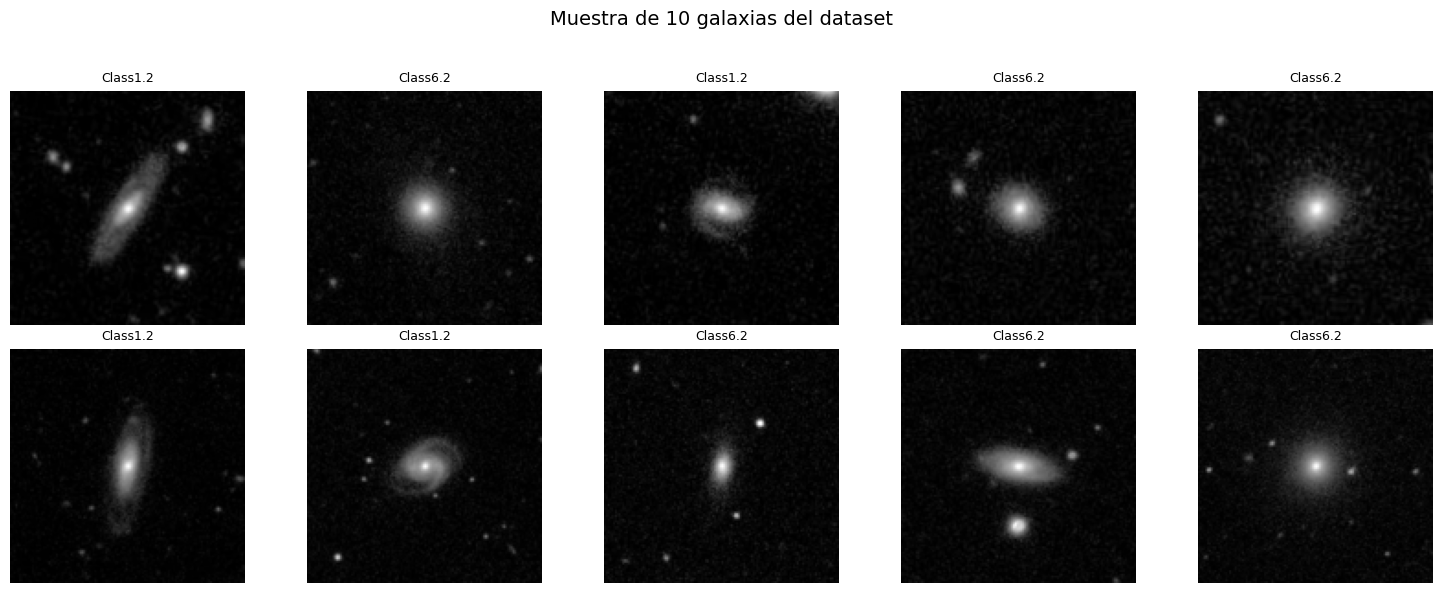

Clases: ['Class1.2', 'Class6.2', 'Class6.1', 'Class1.1', 'Class1.3']
Conteos: [3089, 7162, 708, 1038, 3]


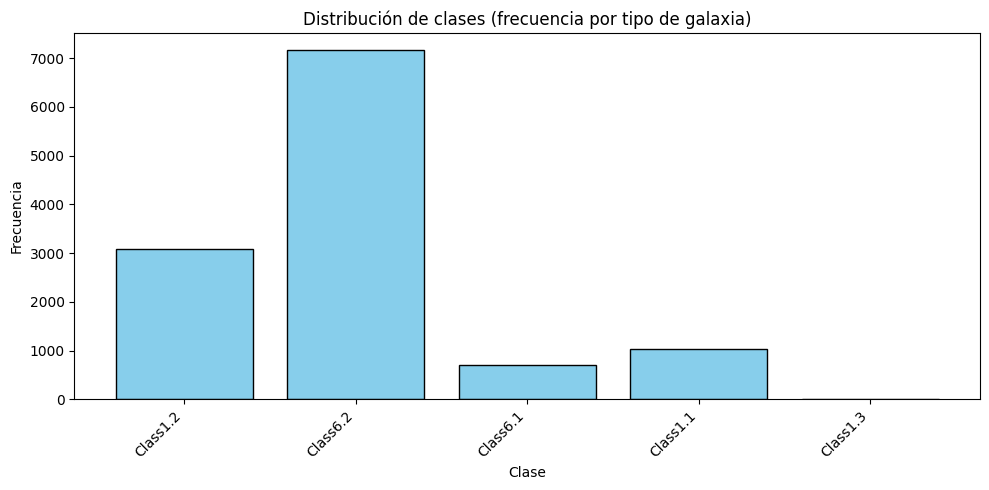

In [ ]:
# ---------------------------------------------------------
# Vista previa de 10 galaxias aleatorias
# ---------------------------------------------------------
n_muestras = min(10, len(X))
indices = np.random.choice(len(X), n_muestras, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.title(y[idx], fontsize=9)
    plt.axis("off")
plt.suptitle("Muestra de 10 galaxias del dataset", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------
from collections import Counter
import pandas as pd

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear tabla con clases y conteos
tabla_frecuencias = pd.DataFrame({
    "Clase": clases,
    "Frecuencia": conteos
}).sort_values("Frecuencia", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Distribución de frecuencias por clase
# ---------------------------------------------------------
from collections import Counter

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

print("Clases:", clases)
print("Conteos:", conteos)

plt.figure(figsize=(10, 5))
plt.bar(clases, conteos, color="skyblue", edgecolor="black")
plt.title("Distribución de clases (frecuencia por tipo de galaxia)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



<Figure size 1000x500 with 0 Axes>

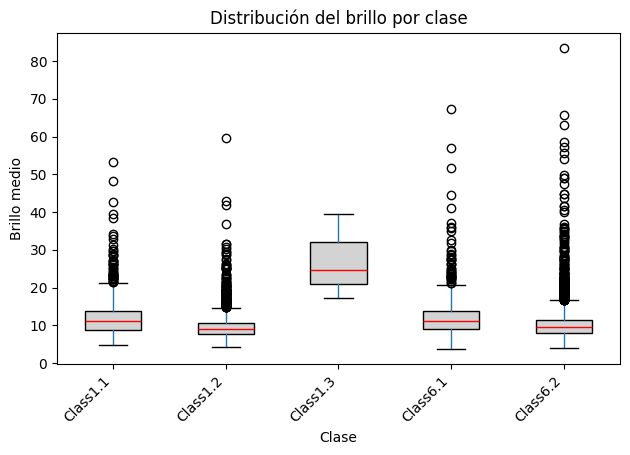

In [ ]:
promedios = [np.mean(img) for img in X]
df = pd.DataFrame({"clase": y, "brillo": promedios})
plt.figure(figsize=(10, 5))
df.boxplot(column="brillo", by="clase", grid=False, patch_artist=True,
           boxprops=dict(facecolor="lightgray", color="black"),
           medianprops=dict(color="red"))
plt.title("Distribución del brillo por clase")
plt.suptitle("")  # quitar título automático de pandas
plt.xlabel("Clase")
plt.ylabel("Brillo medio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Entrenamiento de los modelos


### Division del dataset

In [ ]:
X_r = np.array([img.flatten() for img in X])
print(f"Forma original: {X[0].shape}, forma aplanada: {X_r.shape}")

# 2️⃣ Dividir en conjunto de entrenamiento y prueba (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_r, y,
    test_size=0.30,
    random_state=40,
    stratify=y
)

# 3️⃣ Confirmar tamaños
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("Número de clases:", len(set(y)))

Forma original: (128, 128), forma aplanada: (12000, 16384)
Tamaño del conjunto de entrenamiento: (8400, 16384)
Tamaño del conjunto de prueba: (3600, 16384)
Número de clases: 5


### 1. Regresion Logistica

In [ ]:
modelo = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto")

print("Entrenando modelo de Regresión Logística...")
modelo.fit(X_train, y_train)

print("✅ Entrenamiento completado.")

Entrenando modelo de Regresión Logística...


C:\Users\leon9\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Entrenamiento completado.


In [ ]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)
print("\nReporte completo por clase:")
print(classification_report(y_test, y_pred))



Reporte completo por clase:
              precision    recall  f1-score   support

    Class1.1       0.15      0.12      0.13       311
    Class1.2       0.36      0.35      0.36       927
    Class1.3       0.00      0.00      0.00         1
    Class6.1       0.15      0.11      0.13       212
    Class6.2       0.65      0.69      0.67      2149

    accuracy                           0.52      3600
   macro avg       0.26      0.26      0.26      3600
weighted avg       0.50      0.52      0.51      3600



Precisión global (accuracy): 0.5206


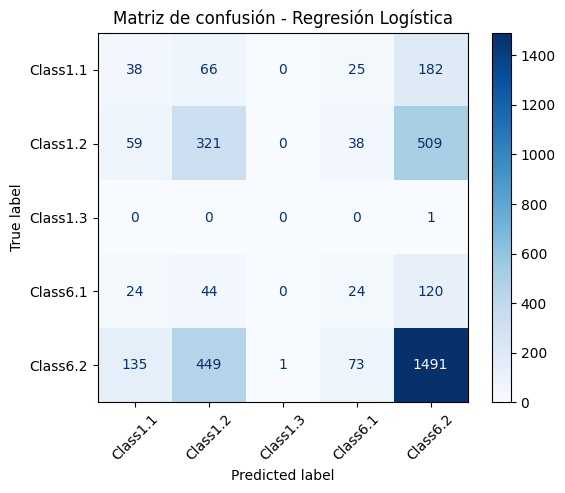

In [ ]:
acc_lr = accuracy_score(y_test, y_pred)
print(f"Precisión global (accuracy): {acc_lr:.4f}")

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=modelo.classes_)

# Mostrar gráfica
disp_lr.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Regresión Logística")
plt.show()